# Final Project - Impact of AI on Students
This is a submission to the final project to the course Supervised Machine Learning: Classification by IBM on Coursera.

In [48]:
#The following packages need to be installed:
!pip install kagglehub[pandas-datasets]
!pip install scikit-learn
!pip install pandas
!pip install numpy
!pip install matplotlib   
!pip install seaborn

In [73]:
#For data handling and processing
import kagglehub
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

#For plotting
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('dark')
sns.set_theme('notebook')
sns.set_context('notebook')

#model_selection
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV

#models
from sklearn.tree import DecisionTreeClassifier

#metrics 
from sklearn.metrics import accuracy_score

# Dataset Selection and Description
The dataset used in this notebook is the dataset "Impact of AI on Students" on Kaggle. As someone who recently graduated from university, I'm curious to see how AI usage affects current students. In particular, I will be studying the impact of AI on the risk of burnout among students.

## Source
This data is publicly available on Kaggle. It can be found on the Kaggle wesbite [here](https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students/data). We load it into a pandas dataframe.

In [50]:
# Import the latest version of the data into a pandas DataFrame
kagglehub.dataset_download("laveshjadon/ai-impact-on-students")

df = kagglehub.dataset_load(
  kagglehub.KaggleDatasetAdapter.PANDAS,
  "laveshjadon/ai-impact-on-students",
  'ai_student_impact_dataset (1).csv'
)
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


## Key Features and the Target
We are interested in the features related to AI. Those are the following:
| Feature Name     | Description |
| ----------- | ----------- |
| Weekly_GenAI_Hours      | Average hours per week spent using Generative AI tools      |
| Primary_Use_Case   | Main purpose for which the student uses AI        |
| Prompt_Engineering_Skill   | Self-assessed proficiency in crafting effective prompts        |
| Tool_Diversity      | Number of distinct AI tools used        |
| Paid_Subscription    | Whether the student has a paid AI subscription        |

The target variable is 'Burnout_Risk_Level'. This is the assesed burnout risk.

We are not interested in any of the other features.

In [51]:
#Eliminate all other features
feature_names = [
    'Weekly_GenAI_Hours',
    'Primary_Use_Case',
    'Prompt_Engineering_Skill',
    'Tool_Diversity',
    'Paid_Subscription'
]

df = df.drop([
    column for column in df.columns
    if column not in feature_names
    and column != 'Burnout_Risk_Level'
    ],
    axis= 1
)

# Analytical Approach and Model Development
We analyze the dataset. Then we train several models on this dataset.

## Structure
We observe 50k rows, none of which have any missing values. However, there are some string-types and a boolean that will need to be encoded.

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Weekly_GenAI_Hours        50000 non-null  float64
 1   Primary_Use_Case          50000 non-null  str    
 2   Prompt_Engineering_Skill  50000 non-null  str    
 3   Tool_Diversity            50000 non-null  int64  
 4   Paid_Subscription         50000 non-null  bool   
 5   Burnout_Risk_Level        50000 non-null  str    
dtypes: bool(1), float64(1), int64(1), str(3)
memory usage: 2.0 MB


The following manipulations are required:
- The target Burnout_Risk_Level needs to be label-encoded
- Primary_Use_Case needs to be one-hot encoded
- Prompt_Engineering_Skill needs to ordinal-encoded
- Paid_Subscription needs to be converted to an integer

In [53]:
## label-encode the target
burnout_encoder = LabelEncoder()
df['Burnout_Risk_Level'] = burnout_encoder.fit_transform(df['Burnout_Risk_Level'])

In [54]:
## Convert Paid_Subscription to int
df['Paid_Subscription'] = df['Paid_Subscription'].astype(int)


In [55]:
## Label encode prompt-engineering skills
df['Prompt_Engineering_Skill'].unique()

<StringArray>
['Beginner', 'Advanced', 'Intermediate']
Length: 3, dtype: str

In [56]:
prompt_engineering_encoder = OrdinalEncoder()

df['Prompt_Engineering_Skill'] = prompt_engineering_encoder.fit_transform(df[['Prompt_Engineering_Skill']])

In [57]:
## One-hot-encode Primary_Use_Case using pandas get_dummies
df = pd.get_dummies(df, drop_first=True, dtype= int)

We observe that every column is now numerical

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Weekly_GenAI_Hours                          50000 non-null  float64
 1   Prompt_Engineering_Skill                    50000 non-null  float64
 2   Tool_Diversity                              50000 non-null  int64  
 3   Paid_Subscription                           50000 non-null  int64  
 4   Burnout_Risk_Level                          50000 non-null  int64  
 5   Primary_Use_Case_Debugging/Troubleshooting  50000 non-null  int64  
 6   Primary_Use_Case_Direct_Answer_Generation   50000 non-null  int64  
 7   Primary_Use_Case_Ideation                   50000 non-null  int64  
 8   Primary_Use_Case_Summarizing_Reading        50000 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 3.4 MB


In [59]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Weekly_GenAI_Hours,50000.0,8.427752,8.269490,0.0,2.39,5.8,11.72,40.0
Prompt_Engineering_Skill,50000.0,1.077740,0.789980,0.0,0.00,1.0,2.00,2.0
Tool_Diversity,50000.0,2.800260,1.188020,1.0,2.00,3.0,4.00,5.0
Paid_Subscription,50000.0,0.423080,0.494053,0.0,0.00,0.0,1.00,1.0
Burnout_Risk_Level,50000.0,1.173140,0.801658,0.0,1.00,1.0,2.00,2.0
Primary_Use_Case_Debugging/Troubleshooting,50000.0,0.245900,0.430624,0.0,0.00,0.0,0.00,1.0
Primary_Use_Case_Direct_Answer_Generation,50000.0,0.126800,0.332752,0.0,0.00,0.0,0.00,1.0
Primary_Use_Case_Ideation,50000.0,0.214420,0.410423,0.0,0.00,0.0,0.00,1.0
Primary_Use_Case_Summarizing_Reading,50000.0,0.172660,0.377957,0.0,0.00,0.0,0.00,1.0


## Target Analysis
We start by plotting the distribution of the target. 
Observe that the dataset is slightly skewed, but it's not drastic enough to warrant extensive correction. 

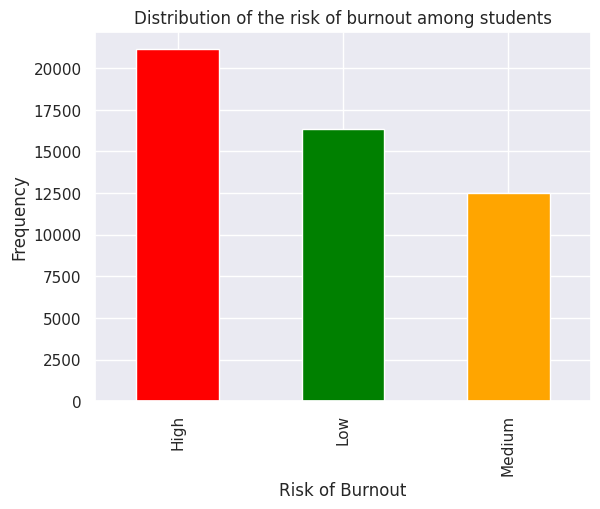

In [60]:
df['Burnout_Risk_Level'].value_counts().plot.bar(color= ['red', 'green', 'orange'])
plt.xlabel('Risk of Burnout')
plt.ylabel('Frequency')
plt.title('Distribution of the risk of burnout among students')
plt.xticks([0, 1, 2], burnout_encoder.inverse_transform([0, 1, 2]));

## Splitting the Data
We use StratifiedShuffleSplit to preserve the distribution presented above.

In [61]:
X = df.drop('Burnout_Risk_Level', axis=1)
y = df['Burnout_Risk_Level']

sss = StratifiedShuffleSplit(test_size= 0.2)
train_idx, test_idx = next(sss.split(X, y))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Fitting models
We first try to fit a decision tree classifier, to see if we are able to overfit the data. It's often easier to regularize an overfit model than to start with regularizating.

In [71]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

y_pred = dtc.predict(X_test)

print('Training accuracy:', accuracy_score(y_train, dtc.predict(X_train)))
print('Testing accuracy:', accuracy_score(y_test, y_pred))

Training accuracy: 0.93355
Testing accuracy: 0.4233
